# Practice 1
## Statistical learning with deep artificial neural networks

## Introduction

In this activity we propose the implementation of a dense deep neural network for
prediction of the severity of Parkinson's disease from data captured by telemonitoring
of the voice (16 variables) of 42 patients. Additional information about the data is
can be found at: https://archive.ics.uci.edu/ml/datasets/Parkinsons+Telemonitoring.


# Solution

1. Cargar el fichero de datos parkinsons_updrs.data.

In [1]:
import pandas as pd
import numpy as np
file_path = "parkinsons_updrs.data"
dat = pd.read_csv(file_path, header=0, sep=",", encoding="latin1") # el 0 equivale a TRUE, en caso contrario se pone None

2. Realizar un descriptiva de las variables del dataset.

In [2]:
dat.shape

(5875, 22)

In [3]:
dat.head()

,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,1,72,0,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,...,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,72,0,12.6660,28.447,34.894,0.00300,0.000017,0.00132,0.00150,...,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,1,72,0,19.6810,28.695,35.389,0.00481,0.000025,0.00205,0.00208,...,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,1,72,0,25.6470,28.905,35.810,0.00528,0.000027,0.00191,0.00264,...,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,1,72,0,33.6420,29.187,36.375,0.00335,0.000020,0.00093,0.00130,...,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361


In [4]:
dat["sex"] = dat["sex"].astype("category") # lo pasa a factor
dat.dtypes # equivalente a str()

subject#            int64
age                 int64
sex              category
test_time         float64
motor_UPDRS       float64
total_UPDRS       float64
Jitter(%)         float64
Jitter(Abs)       float64
Jitter:RAP        float64
Jitter:PPQ5       float64
Jitter:DDP        float64
Shimmer           float64
Shimmer(dB)       float64
Shimmer:APQ3      float64
Shimmer:APQ5      float64
Shimmer:APQ11     float64
Shimmer:DDA       float64
NHR               float64
HNR               float64
RPDE              float64
DFA               float64
PPE               float64
dtype: object

In [5]:
# Univariante
summary = dat.describe(include='all')
print(summary)

           subject#          age     sex    test_time  motor_UPDRS  \
count   5875.000000  5875.000000  5875.0  5875.000000  5875.000000   
unique          NaN          NaN     2.0          NaN          NaN   
top             NaN          NaN     0.0          NaN          NaN   
freq            NaN          NaN  4008.0          NaN          NaN   
mean      21.494128    64.804936     NaN    92.863722    21.296229   
std       12.372279     8.821524     NaN    53.445602     8.129282   
min        1.000000    36.000000     NaN    -4.262500     5.037700   
25%       10.000000    58.000000     NaN    46.847500    15.000000   
50%       22.000000    65.000000     NaN    91.523000    20.871000   
75%       33.000000    72.000000     NaN   138.445000    27.596500   
max       42.000000    85.000000     NaN   215.490000    39.511000   

        total_UPDRS    Jitter(%)  Jitter(Abs)   Jitter:RAP  Jitter:PPQ5  ...  \
count   5875.000000  5875.000000  5875.000000  5875.000000  5875.000000  ...   

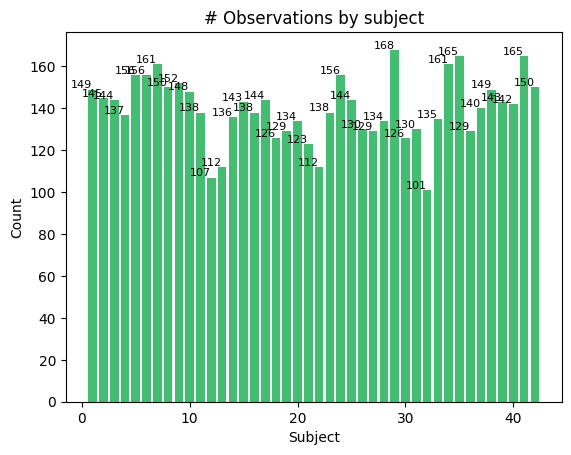

In [6]:
import matplotlib.pyplot as plt
tt = dat['subject#'].value_counts().sort_index() # cuenta las veces de la variable subject i lo ordena
bars = plt.bar(tt.index, tt.values, color=plt.cm.viridis(dat['age'].astype('category').cat.codes / dat['age'].nunique())) 
# el index son las etiquetas i el values son las freq.
plt.title("# Observations by subject")
plt.xlabel("Subject")
plt.ylabel("Count")

for i, value in enumerate(tt.values):
    plt.text(i, value - 0.3, str(value), ha='center', va='bottom', fontsize=8)

plt.show()

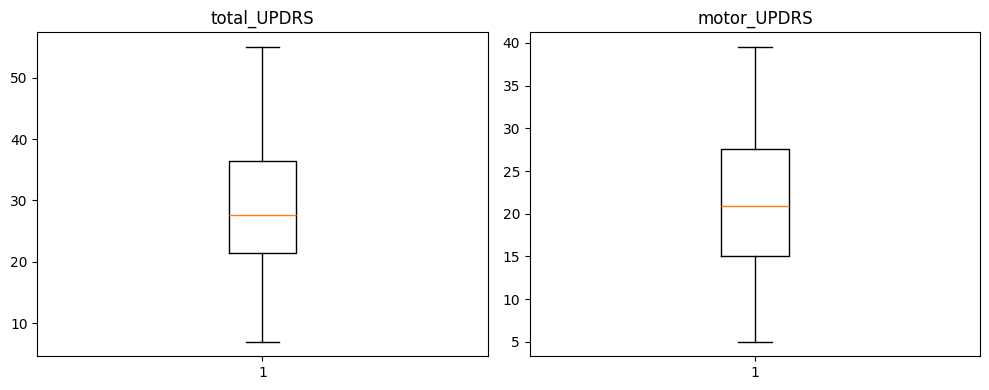

In [7]:
plt.figure(figsize=(10, 4)) # define el alto y ancho de la figura

plt.subplot(1, 2, 1) # equivalente a par(mfrow=c()), una fila dos columnas posicion 1
plt.boxplot(dat['total_UPDRS'])
plt.title("total_UPDRS")

plt.subplot(1, 2, 2) # posicion 2
plt.boxplot(dat['motor_UPDRS'])
plt.title("motor_UPDRS")

plt.tight_layout()
plt.show()


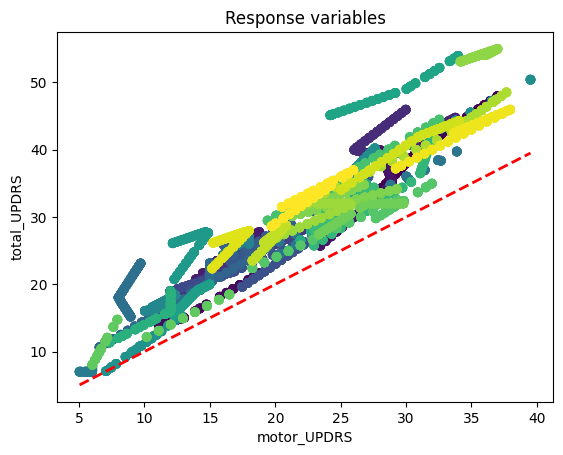

In [8]:
# Bivariante
subjects = dat['subject#'].astype('category').cat.codes  # convierte sujetos a códigos numéricos (0,1,2,...)
# Crear gráfico de dispersión
plt.scatter(
    dat['motor_UPDRS'],       # eje X
    dat['total_UPDRS'],       # eje Y
    c=dat['subject#'].astype('category').cat.codes,  # colores por sujeto
    cmap='viridis'            # paleta de colores
)

# Título y etiquetas
plt.title("Response variables")
plt.xlabel("motor_UPDRS")
plt.ylabel("total_UPDRS")

# Añadir línea y = x (equivalente a abline(a=0,b=1,...))
plt.plot(
    [dat['motor_UPDRS'].min(), dat['motor_UPDRS'].max()],
    [dat['motor_UPDRS'].min(), dat['motor_UPDRS'].max()],
    color='red', linestyle='--', linewidth=2
)

plt.show()

In [9]:
# PCA
import prince
# Convertir la variable cualitativa a string
dat['subject#'] = dat['subject#'].astype(str)

# Seleccionar columnas 1 y 7–22 (Python indexa desde 0)
X = dat.iloc[:, [0] + list(range(6, 22))]

# Quitar la variable cualitativa para el PCA
X_quant = X.drop(X.columns[0], axis=1)

# PCA con todas las componentes posibles
pca = prince.PCA(n_components=X_quant.shape[1]).fit(X_quant)

# Obtener coordenadas de variables (correlaciones con cada componente)
var_coords = pca.column_correlations

# Calcular contribución de cada variable a cada componente
# Fórmula: (coord^2 / sum(coord^2 para esa componente) * 100)
var_contrib = var_coords**2
var_contrib = var_contrib.div(var_contrib.sum(axis=0), axis=1) * 100

# Mostrar resultados, con 6 decimales
pd.set_option('display.float_format', '{:.6f}'.format)
print(var_contrib)

component           0        1         2         3         4         5   \
variable                                                                  
Jitter(%)     7.111863 8.693309  3.324776  0.025894  0.191971  0.011983   
Jitter(Abs)   6.231562 9.282177  0.634415  0.584192  1.206865 18.059313   
Jitter:RAP    6.698493 9.521303  4.791887  0.274463  1.090298  2.567831   
Jitter:PPQ5   7.014391 5.229241  5.790529  0.175404  1.091928  6.930681   
Jitter:DDP    6.698565 9.521363  4.791616  0.274595  1.089921  2.566602   
Shimmer       7.757040 6.796129  0.000159  0.770057  0.078459  0.259315   
Shimmer(dB)   7.773366 6.238917  0.000151  0.492908  0.057719  0.073512   
Shimmer:APQ3  7.241287 8.238801  0.012946  1.572819  0.115746 10.151874   
Shimmer:APQ5  7.535111 7.424208  0.009518  0.969306  0.253174  0.814125   
Shimmer:APQ11 6.845996 6.889057  0.833981  0.645095  0.213563  5.803872   
Shimmer:DDA   7.241264 8.238869  0.012944  1.572982  0.115717 10.151898   
NHR           6.676533 0.

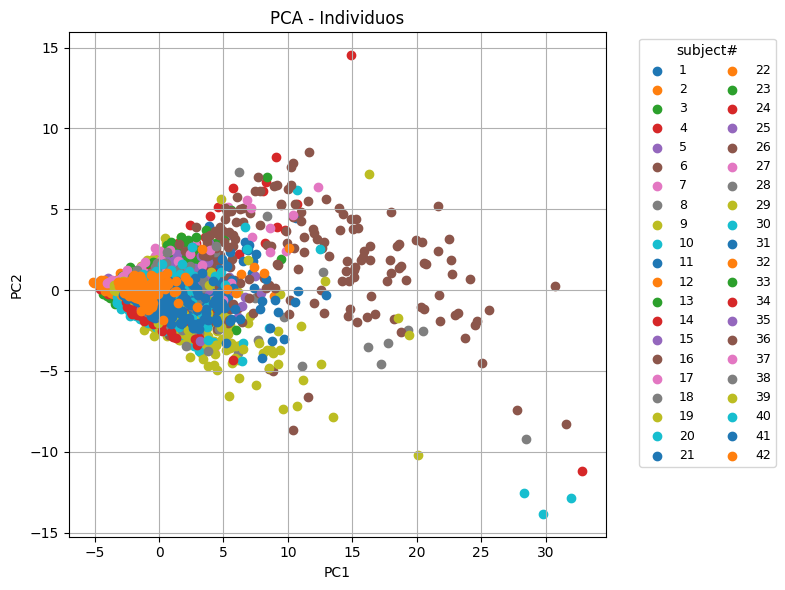

In [10]:
ind_coords = pca.row_coordinates(X)
plt.figure(figsize=(8,6))
for cat in dat['subject#'].unique():
    subset = ind_coords[dat['subject#'] == cat]
    plt.scatter(subset[0], subset[1], label=cat)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA - Individuos')
plt.grid(True)

# Leyenda en dos columnas, fuera del gráfico
plt.legend(title='subject#', ncol=2, fontsize=9, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()  # Ajusta el gráfico para que no se corte la leyenda
plt.show()


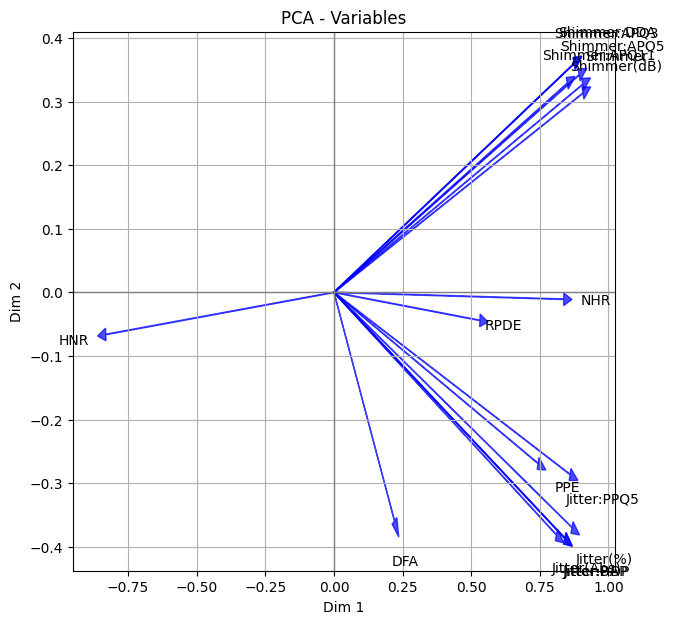

In [11]:
# Coordenadas de las variables en el plano factorial
var_coords = pca.column_correlations

plt.figure(figsize=(7,7))
plt.axhline(0, color='gray', lw=1)
plt.axvline(0, color='gray', lw=1)

# Dibujar flechas para cada variable
for i in range(var_coords.shape[0]):
    plt.arrow(0, 0, var_coords.iloc[i, 0], var_coords.iloc[i, 1],
              color='blue', alpha=0.7, head_width=0.02, length_includes_head=True)
    plt.text(var_coords.iloc[i, 0]*1.1, var_coords.iloc[i, 1]*1.1,
             var_coords.index[i], color='black', ha='center', va='center')

plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.title("PCA - Variables")
plt.grid(True)
plt.show()


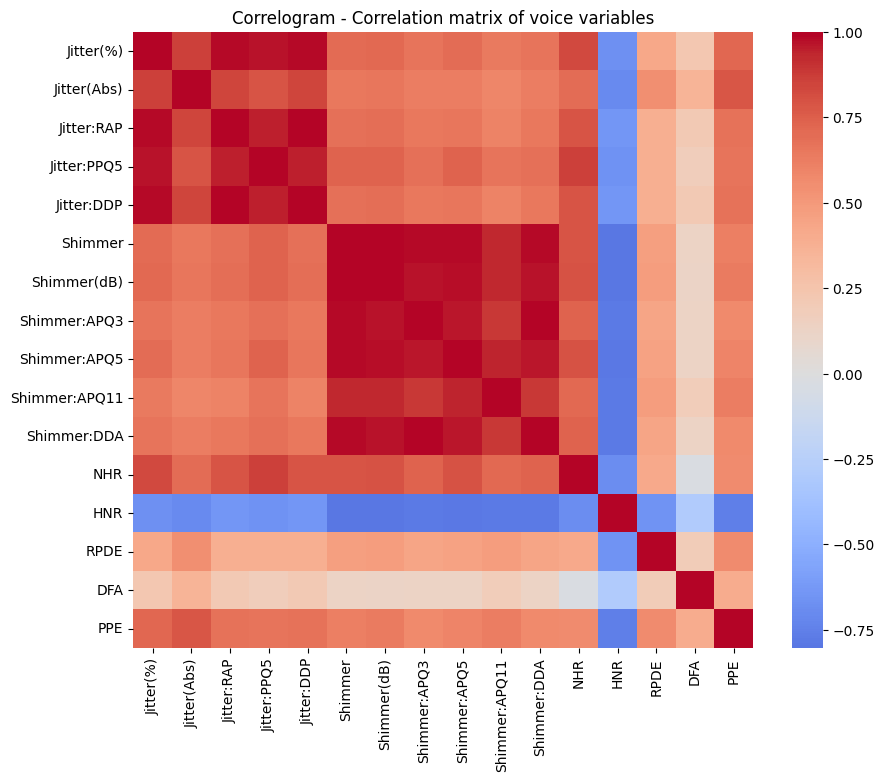

In [12]:
# Matriz de correlación
import seaborn as sns
X_voice = dat.iloc[:, 6:22]
plt.figure(figsize=(10,8))
sns.heatmap(X_voice.corr(), annot=False, cmap='coolwarm', center=0)
plt.title("Correlogram - Correlation matrix of voice variables")
plt.show()

3. Normalizar mediante la transformación min-max las variables de las 16 medidas de voz.

        Jitter(%)  Jitter(Abs)  Jitter:RAP  Jitter:PPQ5  Jitter:DDP  \
count 5875.000000  5875.000000 5875.000000  5875.000000 5875.000000   
mean     0.053689     0.094233    0.046446     0.041181    0.046500   
std      0.056719     0.081164    0.054603     0.053979    0.054597   
min      0.000000     0.000000    0.000000     0.000000    0.000000   
25%      0.027733     0.045529    0.021849     0.020107    0.021847   
50%      0.041045     0.072811    0.033561     0.029799    0.033615   
75%      0.060206     0.115228    0.051739     0.043830    0.051791   
max      1.000000     1.000000    1.000000     1.000000    1.000000   

          Shimmer  Shimmer(dB)  Shimmer:APQ3  Shimmer:APQ5  Shimmer:APQ11  \
count 5875.000000  5875.000000   5875.000000   5875.000000    5875.000000   
mean     0.116637     0.136934      0.096521      0.110275       0.091552   
std      0.097282     0.110646      0.082187      0.100945       0.073217   
min      0.000000     0.000000      0.000000      0.

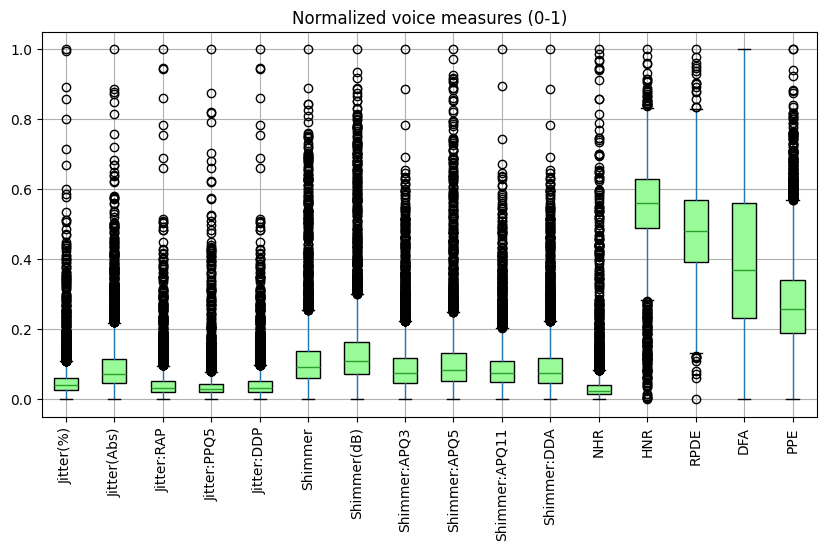

In [13]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
dat_nrm = pd.DataFrame(scaler.fit_transform(X_voice), columns=X_voice.columns) # transform aplica la fórmula (x - min)/(max - min) a cada valor.
print(dat_nrm.describe())
# Boxplot de los datos normalizados
plt.figure(figsize=(10,5))
dat_nrm.boxplot(rot=90, patch_artist=True,
                boxprops=dict(facecolor='palegreen'))
plt.title("Normalized voice measures (0-1)")
plt.show()

4. Crear la variable binaria de severidad del Parkinson.

In [14]:
dat['total_sev'] = np.where(dat['total_UPDRS'] > 25, 1, 0)
print(dat['total_sev'].value_counts())

total_sev
1    3687
0    2188
Name: count, dtype: int64


5. Separar train y test.

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    dat_nrm, dat['total_sev'], test_size=0.3, random_state=123
)

6. Implementar una red neuronal profunda densa para la predicción de la severidad con dos capas ocultas de 10 y 10 nodos cada una.  


In [16]:
import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2

input_shape = X_train.shape[1]

model1 = Sequential([
    Input(shape=(input_shape,)),  # primera capa Input
    Dense(10, activation='relu'),  # sin input_shape aquí
    Dense(10, activation='relu'),
    Dense(1, activation='sigmoid')
])

model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


2026-03-04 13:17:41.116179: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772626661.126142   20175 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772626661.129982   20175 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-04 13:17:41.142136: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1772626662.392447   20175 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22

In [17]:
# --------------------------
# 2️⃣ Entrenamiento de los modelos
# --------------------------

history1 = model1.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.3, verbose=0)


I0000 00:00:1772626663.554513   20246 service.cc:148] XLA service 0x7396b4005ce0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772626663.554535   20246 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2026-03-04 13:17:43.570011: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1772626663.654178   20246 cuda_dnn.cc:529] Loaded cuDNN version 90800
I0000 00:00:1772626664.041846   20246 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [18]:
# --------------------------
# 3️⃣ Evaluación en conjunto de prueba
# --------------------------

score1 = model1.evaluate(X_test, y_test, verbose=0)


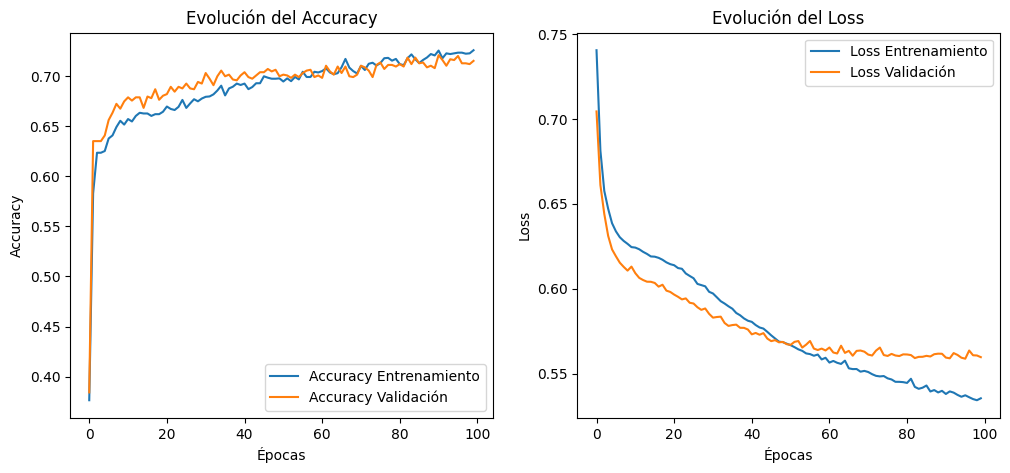

In [19]:
# Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history1.history['accuracy'], label='Accuracy Entrenamiento')
plt.plot(history1.history['val_accuracy'], label='Accuracy Validación')
plt.title('Evolución del Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history1.history['loss'], label='Loss Entrenamiento')
plt.plot(history1.history['val_loss'], label='Loss Validación')
plt.title('Evolución del Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [20]:
from tensorflow.keras.models import load_model
# --------------------------
# Cargar el mejor modelo
# --------------------------
mejor_modelo = load_model('mejor_modelo_model1.keras')

# --------------------------
# Evaluar en conjunto de prueba
# --------------------------
score = mejor_modelo.evaluate(X_test, y_test)
print("Pérdida:", score[0])
print("Exactitud:", score[1])

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7271 - loss: 0.5580   
Pérdida: 0.5426663160324097
Exactitud: 0.7339761853218079


8. Proporcionar las predicciones del dataset de test.

In [21]:
from sklearn.metrics import confusion_matrix, classification_report
# Evaluate the model on the test set
loss, accuracy = model1.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

# Make predictions and threshold at 0.5
pred_probs = model1.predict(X_test)
predtest = (pred_probs > 0.5).astype(int).flatten()  # Ensure shape (n,)

# Compute confusion matrix
cm = confusion_matrix(y_test, predtest)
print("Confusion Matrix (rows=true, columns=predicted):")
print(cm)

# Detailed classification metrics (positive class = 1)
print("\nClassification Report (positive class = 1):")
print(classification_report(y_test, predtest, target_names=['0', '1']))

Test Loss: 0.5438, Test Accuracy: 0.7249
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  
Confusion Matrix (rows=true, columns=predicted):
[[328 327]
 [158 950]]

Classification Report (positive class = 1):
              precision    recall  f1-score   support

           0       0.67      0.50      0.57       655
           1       0.74      0.86      0.80      1108

    accuracy                           0.72      1763
   macro avg       0.71      0.68      0.69      1763
weighted avg       0.72      0.72      0.71      1763



In [22]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, predtest)
precision = precision_score(y_test, predtest)
recall = recall_score(y_test, predtest)       # Sensibilidad
f1 = f1_score(y_test, predtest)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"F1 Score: {f1:.4f}") # combinacion de presicion i sensibilidad.

Accuracy: 0.7249
Precision: 0.7439
Recall (Sensitivity): 0.8574
F1 Score: 0.7966
